# 04 — First `shell_dipole` run on real MDPL2 halos

**Exploratory / diagnostic notebook.** The goal is to *see the estimator behave*
on real data for the first time — not to produce a science result. We load the
MDPL2 halo catalog, carve a boundary-safe sub-volume, run
`dvcorr.estimators.shell_dipole.shell_dipole` around real halos, and check that the
output looks the way the frozen conventions say it should:

- `count(r)` rising ~ `r^2` (geometry is sane),
- `Q = Σμ ≈ 0` (the shell is near-isotropic),
- the normalized dipole `3·Σuμ/ΣN` **negative** and largest at small `r` (infall),
- collapsing toward zero when the velocities are shuffled (the signal is physical).

Nothing here is reimplemented: geometry comes from `dvcorr/geometry.py`, the estimator
from `dvcorr/estimators/shell_dipole.py`, and all conventions (observer, orientation,
sign, columns) from `dvcorr/conventions.py`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree

from dvcorr import conventions
from dvcorr.config import PathsConfig
from dvcorr.geometry import unit_vector
from dvcorr.estimators.shell_dipole import shell_dipole

print("observer (box center):", conventions.OBSERVER_POSITION)
print("BOX_SIZE            :", conventions.BOX_SIZE, " h^-1 Mpc")
print("MAX_ANALYSIS_RADIUS :", conventions.MAX_ANALYSIS_RADIUS, " h^-1 Mpc")

observer (box center): [500. 500. 500.]
BOX_SIZE            : 1000.0  h^-1 Mpc
MAX_ANALYSIS_RADIUS : 500.0  h^-1 Mpc


## Parameters

Everything tunable lives here. `R_SUB` carves a sphere around the observer so
every pair stays away from the box faces (no periodic wrapping needed —
consistent with `pair_separation`'s no-minimum-image contract). Centrals are
drawn only from the **middle** (`R_MID`) so their shells out to `R_MAX` are
fully populated and never truncated by the carve.

In [2]:
# ---- Tunable parameters for this exploratory run -------------------------
DATA_PATH  = str(PathsConfig().mdpl2_catalog)  # <-- MDPL2 catalog; override with your path if different

R_SUB      = 300.0   # h^-1 Mpc : radius of the carved sub-volume around the observer
R_MID      = 150.0   # h^-1 Mpc : centrals drawn from within this radius (the "middle")
R_MAX      =  60.0   # h^-1 Mpc : outermost neighbor separation / outer shell edge
SHELL_STEP =   5.0   # h^-1 Mpc : shell width
N_CENTERS  =  50     # number of centrals to stack in step 6
SEED       =  42     # reproducible central selection and velocity shuffle

SHELL_EDGES = np.arange(0.0, R_MAX + SHELL_STEP, SHELL_STEP)
print("shell_edges:", SHELL_EDGES)

# Guards: shells must fit the minimum-image ceiling, and a middle central's
# shells (reach R_MID + R_MAX from the observer) must stay inside the carve.
assert SHELL_EDGES[-1] <= conventions.MAX_ANALYSIS_RADIUS
assert R_MID + R_MAX <= R_SUB, "middle centrals' shells must fit inside the sub-volume"
print("DATA_PATH:", DATA_PATH)

shell_edges: [ 0.  5. 10. 15. 20. 25. 30. 35. 40. 45. 50. 55. 60.]
DATA_PATH: /home/ofeke2000/Cross-correlating-Tempel-SDSS-groups-with-Cosmicflows-4-peculiar-velocities/data/mdpl2_rockstar_125_pid-1_mvir12.csv


## 1 — Load

Load only the columns we need (positions, velocities, mass) via `usecols`, so
the ~600 MB / ~4M-row catalog does not balloon in memory. Eyeball the ranges:
positions should span roughly `0 .. BOX_SIZE` (comoving `h^-1` Mpc) and
velocities should be a few hundred to a couple thousand km/s.

In [3]:
POS_COLS = list(conventions.POSITION_COLUMNS)
VEL_COLS = list(conventions.VELOCITY_COLUMNS)
MASS_COL = conventions.HALO_COLUMNS["mass"]

usecols = POS_COLS + VEL_COLS + [MASS_COL]
print("loading columns:", usecols)
halos = pd.read_csv(DATA_PATH, usecols=usecols)

print("n halos :", len(halos))
print("columns :", list(halos.columns))
print()
print("position ranges (expect ~0 .. %.0f, comoving h^-1 Mpc):" % conventions.BOX_SIZE)
for c in POS_COLS:
    print(f"  {c}: {halos[c].min():10.2f} .. {halos[c].max():10.2f}")
print("velocity ranges (expect ~ +/- a few 1000 km/s):")
for c in VEL_COLS:
    print(f"  {c}: {halos[c].min():10.1f} .. {halos[c].max():10.1f}")
print(f"mass {MASS_COL}: {halos[MASS_COL].min():.3e} .. {halos[MASS_COL].max():.3e}  (h^-1 M_sun)")

loading columns: ['x', 'y', 'z', 'vx', 'vy', 'vz', 'mvir']


n halos : 4093751
columns : ['mvir', 'x', 'y', 'z', 'vx', 'vy', 'vz']

position ranges (expect ~0 .. 1000, comoving h^-1 Mpc):
  x:       0.00 ..    1000.00
  y:       0.00 ..    1000.00
  z:       0.00 ..    1000.00
velocity ranges (expect ~ +/- a few 1000 km/s):
  vx:    -2661.9 ..     2764.7
  vy:    -2723.3 ..     2776.8
  vz:    -3098.6 ..     2741.7
mass mvir: 1.001e+12 .. 3.503e+15  (h^-1 M_sun)


**Read the numbers above before continuing.** If positions do not span the
box, or velocities look like Mpc rather than km/s, the units are wrong and
nothing downstream is meaningful.

## 2 — Carve a sub-volume (periodicity guard)

Keep only halos within `R_SUB` of the observer (box center). Because the
observer sits at `(500, 500, 500)` and `R_SUB = 300`, the sub-volume lives well
inside `[200, 800]` on every axis — far from the box faces — so a plain
Euclidean difference *is* the minimum image, and no wrapping is required.

In [4]:
observer = np.asarray(conventions.OBSERVER_POSITION, dtype=float)

pos_all = halos[POS_COLS].to_numpy(dtype=float)
vel_all = halos[VEL_COLS].to_numpy(dtype=float)

d_obs  = np.linalg.norm(pos_all - observer, axis=1)
in_sub = d_obs <= R_SUB

pos = pos_all[in_sub]
vel = vel_all[in_sub]

print(f"halos within R_SUB = {R_SUB} h^-1 Mpc of the observer: "
      f"{in_sub.sum()} of {len(halos)} ({100*in_sub.mean():.2f}%)")
print("carved position ranges (should sit well inside [0, %.0f], away from faces):"
      % conventions.BOX_SIZE)
for j, c in enumerate(POS_COLS):
    print(f"  {c}: {pos[:, j].min():8.2f} .. {pos[:, j].max():8.2f}")

halos within R_SUB = 300.0 h^-1 Mpc of the observer: 464764 of 4093751 (11.35%)
carved position ranges (should sit well inside [0, 1000], away from faces):
  x:   200.13 ..   799.26
  y:   200.29 ..   798.97
  z:   200.49 ..   799.74


### Precompute the observer-frame radial velocity of every carved halo

For neighbor `i`, the weight fed to the estimator is
`u_i = v_i · n̂_V,i`, with `n̂_V,i` the **observer → neighbor** direction.
This is a per-halo scalar, independent of which central we pick, so compute it
once here. (Note this is `n̂_V`, the neighbor's line of sight — distinct from
`n̂_T`, the central's, which `shell_dipole` builds internally for `μ`.)

In [5]:
# u_i = v_i . n_hat_V,i  (observer-frame radial peculiar velocity), one per halo.
n_hat_V = unit_vector(pos - observer)      # (M, 3)
u_all   = np.sum(vel * n_hat_V, axis=1)    # (M,)
assert np.all(np.isfinite(u_all))          # missing velocity would be missing data (hard rule 5)
print("u_all [km/s]:  mean %7.2f   std %7.2f   min %8.1f   max %8.1f"
      % (u_all.mean(), u_all.std(), u_all.min(), u_all.max()))

# KDTree on the carved sub-volume. Plain Euclidean: we carved away from the box
# faces, so within the sub-volume no periodic wrapping is needed — consistent
# with pair_separation's no-minimum-image contract.
tree = cKDTree(pos)
print("KDTree built on", len(pos), "halos")

u_all [km/s]:  mean   -1.68   std  320.52   min  -2243.8   max   2144.4


KDTree built on 464764 halos


## 3 — Pick one central object (from the middle)

Draw a single central at random from halos within `R_MID` of the observer, with
a fixed seed for reproducibility. A central this deep inside the sub-volume has
its full `R_MAX` neighborhood populated; an edge halo would have shells sliced
by the carve, faking an anisotropy (a spurious dipole).

In [6]:
rng = np.random.default_rng(SEED)

d_sub  = np.linalg.norm(pos - observer, axis=1)
middle = np.where(d_sub <= R_MID)[0]
print(f"candidate centrals within R_MID = {R_MID}: {middle.size}")

central_idx = int(rng.choice(middle))
s_center    = pos[central_idx]
R_center    = np.linalg.norm(s_center - observer)

nbr = tree.query_ball_point(s_center, R_MAX)
nbr = np.asarray([j for j in nbr if j != central_idx], dtype=int)  # drop self (r = 0)

print(f"central index (into carved arrays): {central_idx}")
print(f"central position                  : {s_center}")
print(f"R = |s_center - observer|         : {R_center:.2f} h^-1 Mpc")
print(f"neighbors within r_max = {R_MAX} : {nbr.size}")

candidate centrals within R_MID = 150.0: 57607
central index (into carved arrays): 40799
central position                  : [594.783 498.288 488.397]
R = |s_center - observer|         : 95.51 h^-1 Mpc
neighbors within r_max = 60.0 : 3400


## 4 — Run the estimator on the single central

Two calls into the same estimator:

- `weights = u_i` → `.dipole = Σ u_i μ_i` (the physical numerator) and
  `.monopole = Σ u_i` (the geometry/leakage diagnostic that travels with it),
- `weights = None` → `.dipole = Σ μ_i = Q` (the pure geometric dipole).

The normalized dipole is `3·Σuμ / N` (the `3 = 2ℓ+1`), masked where a shell is
empty. For a single central this will be **noisy** — that is expected.

In [7]:
s_neighbors = pos[nbr]
u_nbr       = u_all[nbr]

res_u    = shell_dipole(s_center, s_neighbors, SHELL_EDGES, weights=u_nbr, observer=observer)
res_geom = shell_dipole(s_center, s_neighbors, SHELL_EDGES, weights=None,  observer=observer)

rc    = res_u.shell_centers
count = res_u.pair_count
Q     = res_geom.dipole            # sum(mu * 1) = sum(mu)
dip   = res_u.dipole               # sum(u * mu)
with np.errstate(invalid="ignore", divide="ignore"):
    norm_dip = np.where(count > 0, 3.0 * dip / count, np.nan)

print(f"{'r_cen':>7} {'count':>7} {'Q=Sum_mu':>11} {'Sum_u_mu':>12} {'3*Sum_u_mu/N [km/s]':>20}")
for i in range(len(rc)):
    print(f"{rc[i]:7.1f} {count[i]:7.0f} {Q[i]:11.3f} {dip[i]:12.1f} {norm_dip[i]:20.2f}")

  r_cen   count    Q=Sum_mu     Sum_u_mu  3*Sum_u_mu/N [km/s]
    2.5       5      -1.589       -515.5              -309.33
    7.5      41      14.904       1282.6                93.85
   12.5      52       8.205      -3457.4              -199.46
   17.5     116      21.867     -15906.3              -411.37
   22.5     130      17.513     -12023.6              -277.47
   27.5     164       6.789     -14235.6              -260.41
   32.5     272      20.558     -19331.0              -213.21
   37.5     406     -33.751     -25686.8              -189.80
   42.5     430     -39.445     -19686.2              -137.35
   47.5     529     -61.134     -19817.2              -112.38
   52.5     567     -24.040      -8074.0               -42.72
   57.5     688     -54.404       7106.5                30.99


## 5 — Plot the single-central diagnostics

Three panels, shared separation axis:

**(a)** `count` vs `r` — should climb ~ `r^2` for a near-uniform field
(dashed guide). **(b)** `Q = Σμ` vs `r` — should hover near zero (isotropic
shell). **(c)** normalized dipole `3·Σuμ/N` [km/s] — the physical signal;
expect negative, largest at small `r`, noisy for one central.

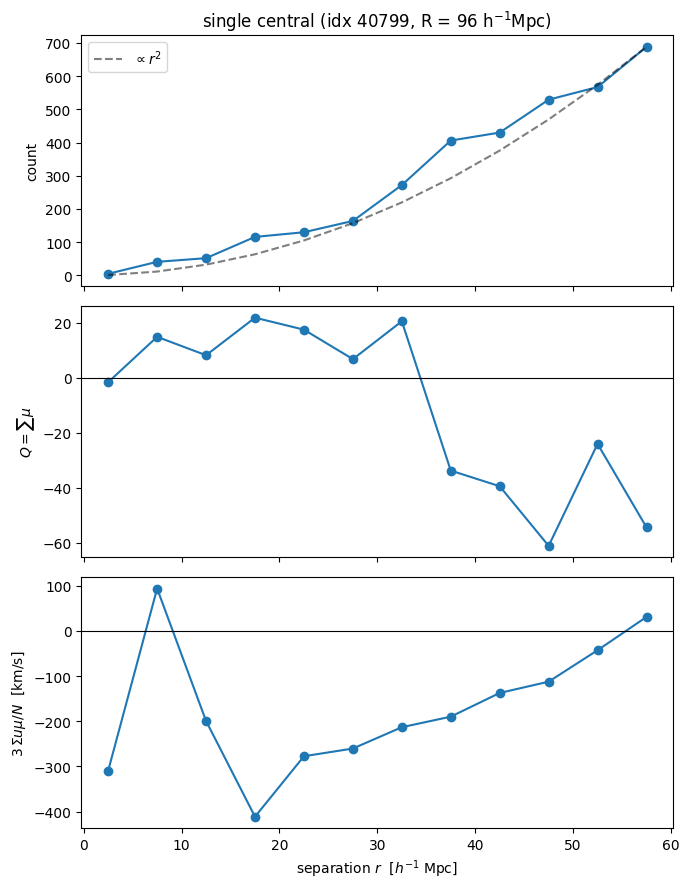

In [8]:
fig, ax = plt.subplots(3, 1, figsize=(7, 9), sharex=True)

ax[0].plot(rc, count, "o-")
ref = count[-1] * (rc / rc[-1])**2          # r^2 reference, scaled to the outer shell
ax[0].plot(rc, ref, "k--", alpha=0.5, label=r"$\propto r^2$")
ax[0].set_ylabel("count"); ax[0].legend()
ax[0].set_title("single central (idx %d, R = %.0f h$^{-1}$Mpc)" % (central_idx, R_center))

ax[1].plot(rc, Q, "o-")
ax[1].axhline(0, color="k", lw=0.8)
ax[1].set_ylabel(r"$Q=\sum\mu$")

ax[2].plot(rc, norm_dip, "o-")
ax[2].axhline(0, color="k", lw=0.8)
ax[2].set_ylabel(r"$3\,\Sigma u\mu / N$  [km/s]")
ax[2].set_xlabel(r"separation $r$  [$h^{-1}$ Mpc]")

plt.tight_layout(); plt.show()

## 6 — Stack many centrals

Repeat steps 3–4 for `N_CENTERS` centrals drawn from the middle, and **sum the
raw `dipole` and `count` arrays across centrals, then normalize**:
`3·ΣΣuμ / ΣΣN`. This is the correct stacked estimator — *not* the mean of the
per-central normalized dipoles (that up-weights sparse shells and is a worse
estimator). We also carry the stacked monopole `Σu/ΣN` alongside (hard rule 6:
the dipole is never reported without its geometry diagnostic).

In [9]:
def measure_center(idx, shuffle_rng=None):
    """Raw per-shell sums (pair_count, dipole, monopole) for one central.

    If shuffle_rng is given, the neighbor u values are permuted among the
    neighbor positions — the velocity-shuffle null of step 7."""
    n_shells = len(SHELL_EDGES) - 1
    c = pos[idx]
    js = tree.query_ball_point(c, R_MAX)
    js = np.asarray([j for j in js if j != idx], dtype=int)   # drop self
    if js.size == 0:
        z = np.zeros(n_shells)
        return z.copy(), z.copy(), z.copy()
    w = u_all[js].copy()
    if shuffle_rng is not None:
        w = w[shuffle_rng.permutation(w.size)]
    r = shell_dipole(pos[idx], pos[js], SHELL_EDGES, weights=w, observer=observer)
    return r.pair_count, r.dipole, r.monopole


rng     = np.random.default_rng(SEED)
centers = rng.choice(middle, size=min(N_CENTERS, middle.size), replace=False)
print(f"stacking {centers.size} centrals")

sum_count = np.zeros(len(SHELL_EDGES) - 1)
sum_dip   = np.zeros_like(sum_count)
sum_mono  = np.zeros_like(sum_count)
for idx in centers:
    c_, d_, m_ = measure_center(int(idx))
    sum_count += c_; sum_dip += d_; sum_mono += m_

with np.errstate(invalid="ignore", divide="ignore"):
    stack_norm = np.where(sum_count > 0, 3.0 * sum_dip / sum_count, np.nan)
    stack_mono = np.where(sum_count > 0, sum_mono / sum_count, np.nan)

print(f"{'r_cen':>7} {'Sum_count':>10} {'3*SSum_u_mu/SN [km/s]':>22} {'Su/SN [km/s]':>15}")
for i in range(len(rc)):
    print(f"{rc[i]:7.1f} {sum_count[i]:10.0f} {stack_norm[i]:22.2f} {stack_mono[i]:15.2f}")

stacking 50 centrals
  r_cen  Sum_count  3*SSum_u_mu/SN [km/s]    Su/SN [km/s]
    2.5        334                 -39.06            1.24
    7.5       1182                -146.81           45.96
   12.5       2675                 -80.45           40.24
   17.5       4467                 -94.42           49.15
   22.5       7106                 -70.66           45.46
   27.5      10029                 -64.47           38.07
   32.5      13749                 -52.84           24.52
   37.5      17845                 -35.37           15.77
   42.5      23196                 -30.55           16.51
   47.5      28350                  -7.32           15.74
   52.5      34081                  -0.19           15.99
   57.5      42020                   3.12           20.12


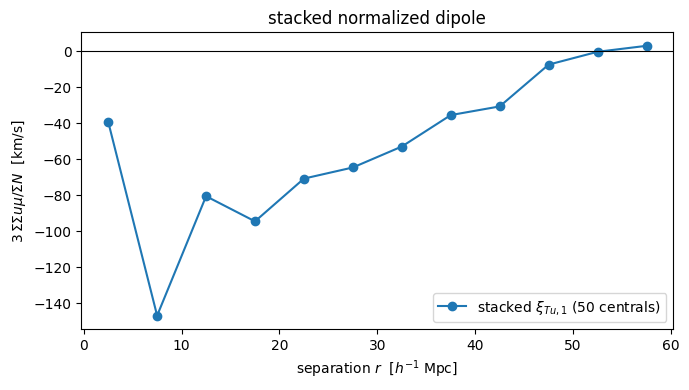

In [10]:
fig, axs = plt.subplots(figsize=(7, 4))
axs.plot(rc, stack_norm, "o-", label="stacked $\\xi_{Tu,1}$ (%d centrals)" % centers.size)
axs.axhline(0, color="k", lw=0.8)
axs.set_xlabel(r"separation $r$  [$h^{-1}$ Mpc]")
axs.set_ylabel(r"$3\,\Sigma\Sigma u\mu / \Sigma N$  [km/s]")
axs.set_title("stacked normalized dipole")
axs.legend(); plt.tight_layout(); plt.show()

## 7 — Sanity check: velocity-shuffle null

For each central, permute the neighbor `u` values among the neighbor
*positions* before accumulating. This destroys the correlation between velocity
and position while leaving the geometry (`count`, `μ` distribution) and the
velocity distribution untouched. If the stacked signal is physical, the shuffled
dipole should **collapse toward zero**. This is the most convincing single
demonstration that we are measuring infall and not a geometric artifact.

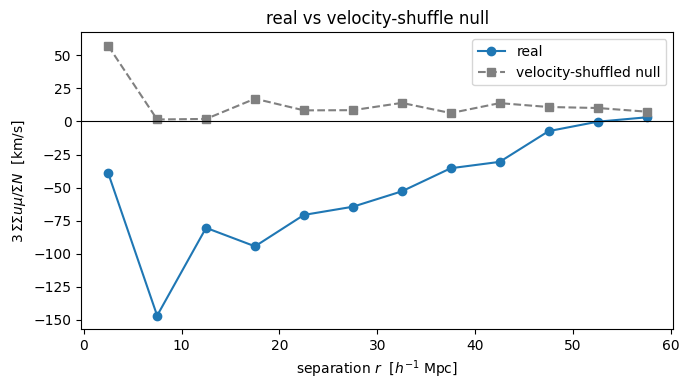

real   normalized dipole [km/s]: [ -39.06 -146.81  -80.45  -94.42  -70.66  -64.47  -52.84  -35.37  -30.55
   -7.32   -0.19    3.12]
shuffled normalized dipole [km/s]: [57.18  1.49  1.91 17.2   8.39  8.52 14.03  6.34 13.85 10.93 10.17  7.41]


In [11]:
shuf_rng = np.random.default_rng(SEED + 1)
s_count  = np.zeros(len(SHELL_EDGES) - 1)
s_dip    = np.zeros_like(s_count)
for idx in centers:
    c_, d_, _ = measure_center(int(idx), shuffle_rng=shuf_rng)
    s_count += c_; s_dip += d_

with np.errstate(invalid="ignore", divide="ignore"):
    shuf_norm = np.where(s_count > 0, 3.0 * s_dip / s_count, np.nan)

fig, axn = plt.subplots(figsize=(7, 4))
axn.plot(rc, stack_norm, "o-", label="real")
axn.plot(rc, shuf_norm, "s--", color="grey", label="velocity-shuffled null")
axn.axhline(0, color="k", lw=0.8)
axn.set_xlabel(r"separation $r$  [$h^{-1}$ Mpc]")
axn.set_ylabel(r"$3\,\Sigma\Sigma u\mu / \Sigma N$  [km/s]")
axn.set_title("real vs velocity-shuffle null")
axn.legend(); plt.tight_layout(); plt.show()

print("real   normalized dipole [km/s]:", np.round(stack_norm, 2))
print("shuffled normalized dipole [km/s]:", np.round(shuf_norm, 2))

### What to conclude

- **count ~ r²** and **Q ≈ 0** ⇒ the geometry and the shell sampling are sane.
- **stacked dipole negative, largest at small r** ⇒ coherent infall, with the
  sign the frozen convention predicts (infall ⇒ negative dipole).
- **shuffled null ≈ 0** ⇒ the signal is the velocity–density correlation, not a
  geometric artifact.

If the real stacked dipole came out *positive*, that is an orientation bug
(a flipped pair vector), not a result — see `dvcorr/conventions.py` and hard rule 2.

---

# Larger, error-bounded stacked measurement

Everything above (300 h$^{-1}$ Mpc carve, 50 centers, separations to 60) is left
intact. This section redoes the stack on a **bigger sub-volume**, out to **larger
separations**, with **more centers**, and adds a diagnostic error band — while
keeping the N=50 result above available for the turnover comparison in the last
step.

- `R_SUB2 = 480` h$^{-1}$ Mpc — the observer is at the box center (500), so this
  reaches `[20, 980]` on each axis, still clear of the faces: no periodic
  wrapping.
- separations `0 .. 200` h$^{-1}$ Mpc, with **5 Mpc bins to 60 then 10 Mpc bins**
  (pair counts grow ~ r², so fine bins are wasteful where the signal is flat).
- centers drawn from **within 250** h$^{-1}$ Mpc of the observer so that a full
  `r_max = 200` neighborhood fits inside the carve (asserted below).
- `N_CENTERS2 = 300`.

In [12]:
# ---- Parameters for the larger, error-bounded run ------------------------
R_SUB2     = 480.0   # h^-1 Mpc : larger carve; observer at 500 -> reaches [20, 980], clear of the faces
R_MAX2     = 200.0   # h^-1 Mpc : outermost separation
R_MID2     = 250.0   # h^-1 Mpc : centers drawn within this radius of the observer
N_CENTERS2 = 300
SEED2      = 42

# Variable-width shell edges: 5 Mpc bins out to 60, 10 Mpc bins from 60 to 200.
# Built explicitly with np.concatenate so the widths are visible and intentional.
edges_fine   = np.arange(0.0, 60.0 + 5.0, 5.0)      # 0, 5, ..., 60
edges_coarse = np.arange(70.0, 200.0 + 10.0, 10.0)  # 70, 80, ..., 200
SHELL_EDGES2 = np.concatenate([edges_fine, edges_coarse])
print("SHELL_EDGES2:", SHELL_EDGES2)
print("bin widths  :", np.diff(SHELL_EDGES2))

assert SHELL_EDGES2[-1] <= conventions.MAX_ANALYSIS_RADIUS
assert np.all(np.diff(SHELL_EDGES2) > 0), "shell edges must be strictly increasing"

# A center must sit at least r_max INSIDE the sub-volume, else its outer shells
# are truncated by the carve and fake a dipole. Enforce it, don't assume it:
assert R_MID2 + R_MAX2 <= R_SUB2, (
    f"centers within {R_MID2} of the observer, with neighbors out to {R_MAX2}, "
    f"reach {R_MID2 + R_MAX2} h^-1 Mpc -- must stay <= R_SUB2 = {R_SUB2}."
)
print(f"center-margin OK: R_MID2 + R_MAX2 = {R_MID2 + R_MAX2} <= R_SUB2 = {R_SUB2} "
      f"(centers are at least r_max={R_MAX2} inside the {R_SUB2}-Mpc carve)")

SHELL_EDGES2: [  0.   5.  10.  15.  20.  25.  30.  35.  40.  45.  50.  55.  60.  70.
  80.  90. 100. 110. 120. 130. 140. 150. 160. 170. 180. 190. 200.]
bin widths  : [ 5.  5.  5.  5.  5.  5.  5.  5.  5.  5.  5.  5. 10. 10. 10. 10. 10. 10.
 10. 10. 10. 10. 10. 10. 10. 10.]
center-margin OK: R_MID2 + R_MAX2 = 450.0 <= R_SUB2 = 480.0 (centers are at least r_max=200.0 inside the 480.0-Mpc carve)


## Re-carve the larger sub-volume (point 1)

Reuses the full-catalog arrays already in memory (`pos_all`, `vel_all`); the
300-Mpc carve above is untouched. Report the new halo count.

In [13]:
d_obs2  = np.linalg.norm(pos_all - observer, axis=1)
in_sub2 = d_obs2 <= R_SUB2
pos2 = pos_all[in_sub2]
vel2 = vel_all[in_sub2]
print(f"halos within R_SUB2 = {R_SUB2} h^-1 Mpc: {in_sub2.sum()} of {len(halos)} "
      f"({100*in_sub2.mean():.2f}%)   [was {in_sub.sum()} at R_SUB = {R_SUB}]")
print("carved position ranges (should sit inside [0, %.0f]):" % conventions.BOX_SIZE)
for j, c in enumerate(POS_COLS):
    print(f"  {c}: {pos2[:, j].min():8.2f} .. {pos2[:, j].max():8.2f}")

# Observer-frame radial velocities and KDTree for the larger carve.
n_hat_V2 = unit_vector(pos2 - observer)
u_all2   = np.sum(vel2 * n_hat_V2, axis=1)
assert np.all(np.isfinite(u_all2))
tree2 = cKDTree(pos2)
print("u_all2 [km/s]: mean %7.2f  std %7.2f" % (u_all2.mean(), u_all2.std()))
print("KDTree built on", len(pos2), "halos")

halos within R_SUB2 = 480.0 h^-1 Mpc: 1891555 of 4093751 (46.21%)   [was 464764 at R_SUB = 300.0]
carved position ranges (should sit inside [0, 1000]):
  x:    20.22 ..   979.81
  y:    20.68 ..   979.46
  z:    20.19 ..   979.65


u_all2 [km/s]: mean    8.50  std  321.64
KDTree built on 1891555 halos


## Center selection (point 3) and per-center measurement

Draw 300 centers from within `R_MID2` of the observer (seeded). For each center
we store its per-shell `dipole` and `count` arrays — both to sum into the stacked
signal and to form the across-center error band.

In [14]:
n_shells2 = len(SHELL_EDGES2) - 1

d_sub2   = np.linalg.norm(pos2 - observer, axis=1)
middle2  = np.where(d_sub2 <= R_MID2)[0]
rng2     = np.random.default_rng(SEED2)
centers2 = rng2.choice(middle2, size=min(N_CENTERS2, middle2.size), replace=False)
print(f"candidate centers within R_MID2 = {R_MID2}: {middle2.size}; stacking {centers2.size}")


def measure_center2(idx, shuffle_rng=None):
    """Per-shell (pair_count, dipole) for one center in the larger carve.

    If shuffle_rng is given, the neighbor u values are permuted among the
    neighbor positions (the velocity-shuffle null)."""
    js = np.asarray(tree2.query_ball_point(pos2[idx], R_MAX2), dtype=int)
    js = js[js != idx]                         # drop self (r = 0)
    if js.size == 0:
        z = np.zeros(n_shells2)
        return z.copy(), z.copy()
    w = u_all2[js].copy()
    if shuffle_rng is not None:
        w = w[shuffle_rng.permutation(w.size)]
    r = shell_dipole(pos2[idx], pos2[js], SHELL_EDGES2, weights=w, observer=observer)
    return r.pair_count, r.dipole


# Per-center arrays: shape (N_centers, B). Storing them (not just running sums)
# is what lets us build both the raw-sum stack and the across-center SEM band.
counts_pc = np.zeros((centers2.size, n_shells2))
dip_pc    = np.zeros((centers2.size, n_shells2))
for k, idx in enumerate(centers2):
    c_, d_ = measure_center2(int(idx))
    counts_pc[k] = c_
    dip_pc[k]    = d_
print("per-center arrays filled:", counts_pc.shape)

candidate centers within R_MID2 = 250.0: 268529; stacking 300


per-center arrays filled: (300, 26)


## Stacked signal with a diagnostic error band (point 4)

Two distinct combinations, both reported:

- **Stacked signal** = `3 · Σ_c dipole_c / Σ_c count_c` — sum the raw numerators
  and denominators across centers, *then* normalize (not a mean of per-center
  normalized values).
- **Error band** = for each shell, take the per-center normalized dipole
  `3·dipole_c / count_c` over every center with `count_c > 0`, and report the
  **standard error of the mean** across those centers, `std / √N_valid`
  (`ddof=1`, needs ≥ 2 valid centers).

In [15]:
def stack_with_errors(counts_pc, dip_pc):
    """Return (stacked, stderr, total_count, n_valid) per shell.

    stacked : 3 * sum_c dip_c / sum_c count_c   (raw sums, then normalize)
    stderr  : across-center standard error of the per-center normalized dipole
              3*dip_c/count_c, using only centers with count_c > 0."""
    total_count = counts_pc.sum(axis=0)
    total_dip   = dip_pc.sum(axis=0)
    with np.errstate(invalid="ignore", divide="ignore"):
        stacked = np.where(total_count > 0, 3.0 * total_dip / total_count, np.nan)

    B = counts_pc.shape[1]
    stderr  = np.full(B, np.nan)
    n_valid = np.zeros(B, dtype=int)
    for b in range(B):
        valid = counts_pc[:, b] > 0            # guard count_c == 0
        n_valid[b] = int(valid.sum())
        if n_valid[b] > 1:
            per_center = 3.0 * dip_pc[valid, b] / counts_pc[valid, b]
            stderr[b] = per_center.std(ddof=1) / np.sqrt(n_valid[b])
    return stacked, stderr, total_count, n_valid


stacked2, stderr2, tot_count2, nvalid2 = stack_with_errors(counts_pc, dip_pc)
rc2 = 0.5 * (SHELL_EDGES2[:-1] + SHELL_EDGES2[1:])

print(f"{'r_cen':>7} {'tot_count':>12} {'stacked[km/s]':>14} {'stderr':>9} {'N_valid':>8}")
for i in range(n_shells2):
    print(f"{rc2[i]:7.1f} {tot_count2[i]:12.0f} {stacked2[i]:14.2f} "
          f"{stderr2[i]:9.2f} {nvalid2[i]:8d}")

  r_cen    tot_count  stacked[km/s]    stderr  N_valid
    2.5         1659         -58.74     19.06      288
    7.5         6570         -54.66     15.15      300
   12.5        14439         -67.91     13.88      300
   17.5        26335         -64.41     12.04      300
   22.5        42429         -57.96     11.70      300
   27.5        62317         -54.09     10.97      300
   32.5        85297         -58.12     11.10      300
   37.5       111958         -47.31     10.99      300
   42.5       143632         -50.37     10.45      300
   47.5       176165         -43.37     10.14      300
   52.5       213939         -38.37     10.05      300
   57.5       256785         -32.18      9.78      300
   65.0       658517         -27.47      9.29      300
   75.0       878566         -26.28      8.35      300
   85.0      1125332         -18.43      7.53      300
   95.0      1400649         -16.84      7.01      300
  105.0      1715523         -15.40      6.49      300
  115.0   

> **Caveat — this is a diagnostic error bar, not a science-grade one.** The SEM
> above treats the centers as **independent** samples. They are not: two centers
> closer than the shell radius share neighbors, and on scales approaching the
> typical inter-center separation the per-center measurements are strongly
> correlated. The independence assumption therefore **underestimates the
> uncertainty on the largest scales** (and, more mildly, everywhere). A correct
> covariance — including the off-diagonal shell-to-shell terms — requires mock
> catalogs, which is a later step. Read the band as "how noisy is the stack",
> not as a calibrated confidence interval.

## Shuffle null at the new N and range, same error treatment (point 6)

Re-run the velocity-shuffle null with 300 centers over the full 0–200 range and
the identical `stack_with_errors` treatment, so the real and null bands are
directly comparable.

In [16]:
shuf_rng2 = np.random.default_rng(SEED2 + 1)
counts_sh = np.zeros((centers2.size, n_shells2))
dip_sh    = np.zeros((centers2.size, n_shells2))
for k, idx in enumerate(centers2):
    c_, d_ = measure_center2(int(idx), shuffle_rng=shuf_rng2)
    counts_sh[k] = c_
    dip_sh[k]    = d_

shuf2, shuf_err2, tot_count_sh, nvalid_sh = stack_with_errors(counts_sh, dip_sh)
# Sanity: shuffling reorders weights among the SAME neighbors, so the counts
# are unchanged shell-by-shell.
assert np.array_equal(tot_count_sh, tot_count2)
print("shuffle null stacked [km/s]:", np.round(shuf2, 2))

shuffle null stacked [km/s]: [-27.85  18.37   3.03  -3.09   2.19   4.6   -2.24   0.48   0.55  -0.97
   2.06   0.28   0.49   1.82   0.6    1.51   0.65   0.97   1.4    1.75
   1.11   0.85   1.33   1.41   0.8    0.91]


## Plot (point 5): stacked dipole with SEM band + pair counts

Main panel: stacked dipole vs separation (km/s), with a filled ±SEM band, the
shuffle null and its own band in a contrasting muted color, and a zero line.
Lower panel (shared x): pair count per shell on a log scale, so thin bins are
visible.

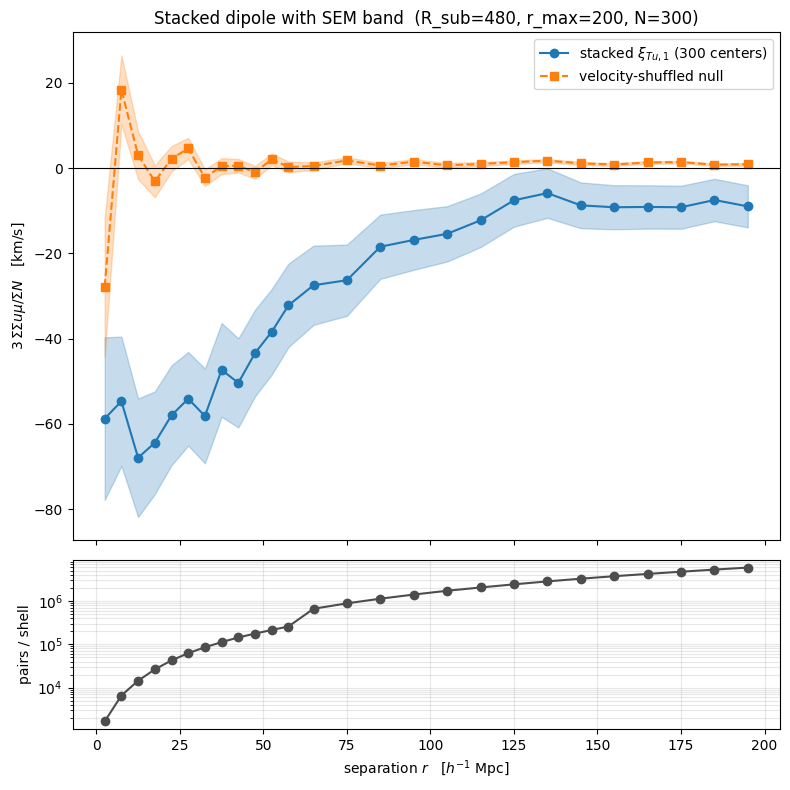

In [17]:
fig, (axA, axB) = plt.subplots(
    2, 1, figsize=(8, 8), sharex=True, gridspec_kw={"height_ratios": [3, 1]}
)

c_sig, c_null = "C0", "C1"

axA.fill_between(rc2, stacked2 - stderr2, stacked2 + stderr2, color=c_sig, alpha=0.25)
axA.plot(rc2, stacked2, "o-", color=c_sig,
         label=r"stacked $\xi_{Tu,1}$ (%d centers)" % centers2.size)
axA.fill_between(rc2, shuf2 - shuf_err2, shuf2 + shuf_err2, color=c_null, alpha=0.25)
axA.plot(rc2, shuf2, "s--", color=c_null, label="velocity-shuffled null")
axA.axhline(0, color="k", lw=0.8)
axA.set_ylabel(r"$3\,\Sigma\Sigma u\mu / \Sigma N$   [km/s]")
axA.set_title("Stacked dipole with SEM band  (R_sub=%.0f, r_max=%.0f, N=%d)"
              % (R_SUB2, R_MAX2, centers2.size))
axA.legend()

axB.plot(rc2, tot_count2, "o-", color="0.3")
axB.set_yscale("log")
axB.set_ylabel("pairs / shell")
axB.set_xlabel(r"separation $r$   [$h^{-1}$ Mpc]")
axB.grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()

## Innermost-bin turnover check (point 7)

Print the innermost-bin pair counts prominently. At N=50 the `r=2.5` bin turned
over (smaller amplitude than its neighbors). With 300 centers we can ask
whether that is small-N noise or a real one-halo / virial effect: look at how
many centers even populate the first bin and the spread of its occupancy.

In [18]:
print("=== Innermost-bin counts (turnover check vs the N=50 run above) ===")
widths2 = np.diff(SHELL_EDGES2)
print(f"{'r_cen':>7} {'width':>6} {'tot_count':>12} {'N_valid':>8} "
      f"{'stacked[km/s]':>14} {'stderr':>9}")
for i in range(6):
    print(f"{rc2[i]:7.1f} {widths2[i]:6.1f} {tot_count2[i]:12.0f} {nvalid2[i]:8d} "
          f"{stacked2[i]:14.2f} {stderr2[i]:9.2f}")

occ0 = counts_pc[:, 0]   # per-center occupancy of the innermost bin
print(f"\ninnermost bin (r_cen = {rc2[0]:.1f}, width {widths2[0]:.1f}) per-center count:")
print(f"  min {occ0.min():.0f}   median {np.median(occ0):.0f}   mean {occ0.mean():.2f}"
      f"   max {occ0.max():.0f}")
print(f"  centers with an empty innermost bin: {(occ0 == 0).sum()} / {centers2.size}")
print("  -> a first bin fed by only a handful of pairs per center, and empty for")
print("     many, points to small-N / virial one-halo noise rather than a robust")
print("     measurement of the correlation at r ~ 2.5 h^-1 Mpc.")

=== Innermost-bin counts (turnover check vs the N=50 run above) ===
  r_cen  width    tot_count  N_valid  stacked[km/s]    stderr
    2.5    5.0         1659      288         -58.74     19.06
    7.5    5.0         6570      300         -54.66     15.15
   12.5    5.0        14439      300         -67.91     13.88
   17.5    5.0        26335      300         -64.41     12.04
   22.5    5.0        42429      300         -57.96     11.70
   27.5    5.0        62317      300         -54.09     10.97

innermost bin (r_cen = 2.5, width 5.0) per-center count:
  min 0   median 5   mean 5.53   max 20
  centers with an empty innermost bin: 12 / 300
  -> a first bin fed by only a handful of pairs per center, and empty for
     many, points to small-N / virial one-halo noise rather than a robust
     measurement of the correlation at r ~ 2.5 h^-1 Mpc.
